# Worksheet 1 - Introduction to image processing in python

#### Notes:
- This is a introductory worksheet and does not to be deliver for evaluation 
- To perform the exercises of this worksheet, you need to use the images "retina.tif" and "P_00001_LEFT_CC.png" that are available in the folder "Auxiliar Images" in the moodle

In [16]:
# command to allow the display of image and plots in the notebook
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
%pylab inline
%matplotlib inline 

%pylab is deprecated, use %matplotlib inline and import the required libraries.
Populating the interactive namespace from numpy and matplotlib


**Question 0**: Read the image "retina_image.png" and visualize it

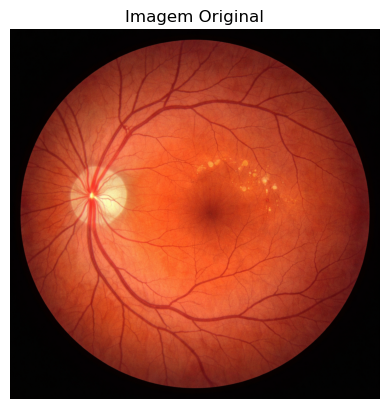

Shape da imagem: (1024, 1024, 3)


In [17]:
# Leitura da imagem retina.tif (altera o nome se necessário)
imagem = mpimg.imread("retina_image.png")

# Mostrar a imagem original
plt.imshow(imagem)
plt.title("Imagem Original")
plt.axis("off")  # Remove eixos
plt.show()

# Verificar dimensões (altura, largura, canais)
print("Shape da imagem:", imagem.shape)

**Question 1**: Read the image "retina.tif" and visualize all the three channels independently. You should use the *subplot* function to visualize the images horizontally and the images should be visualized in grayscale.

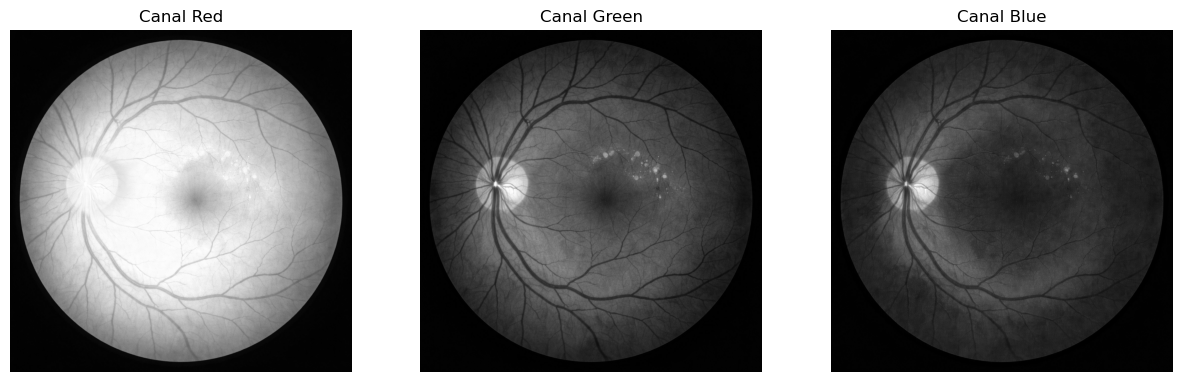

In [18]:
# =============================
# Visualizar canais RGB separadamente
# ==============================

# Separação dos canais
canal_R = imagem[:, :, 0]  # Canal Vermelho
canal_G = imagem[:, :, 1]  # Canal Verde
canal_B = imagem[:, :, 2]  # Canal Azul

# Criar figura com 3 subplots lado a lado
plt.figure(figsize=(15,5))

# Canal R
plt.subplot(1,3,1)
plt.imshow(canal_R, cmap="gray")
plt.title("Canal Red")
plt.axis("off")

# Canal G
plt.subplot(1,3,2)
plt.imshow(canal_G, cmap="gray")
plt.title("Canal Green")
plt.axis("off")

# Canal B
plt.subplot(1,3,3)
plt.imshow(canal_B, cmap="gray")
plt.title("Canal Blue")
plt.axis("off")

plt.show()

**Question 2**: Write a function that receives a RGB image and generates three images corresponding to three-channel images but only with one color component represented. Apply the function to the retina image.

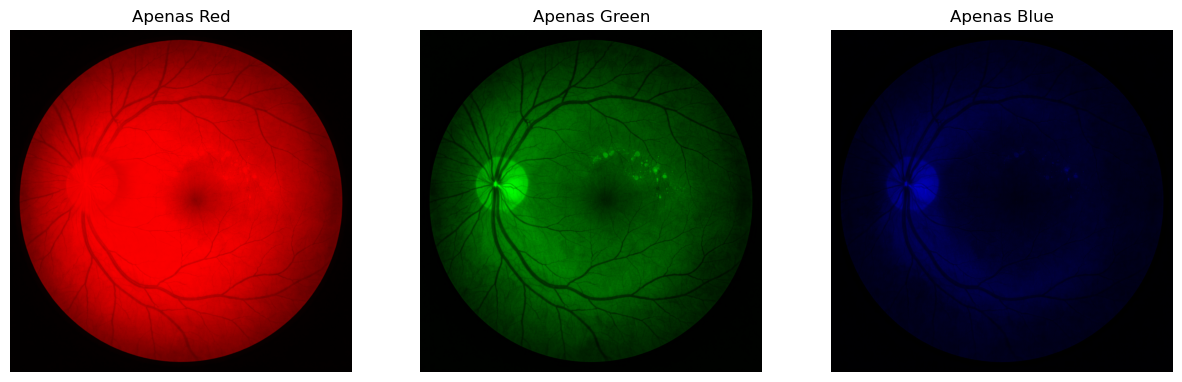

In [19]:
# ==============================
# Função para gerar imagens com um único canal ativo
# ==============================

def separar_canais_rgb(img):
    """
    Recebe imagem RGB e devolve 3 imagens RGB,
    cada uma com apenas um canal ativo.
    """
    
    # Criar cópias da imagem original
    img_R = np.zeros_like(img)
    img_G = np.zeros_like(img)
    img_B = np.zeros_like(img)
    
    # Manter apenas o canal correspondente
    img_R[:, :, 0] = img[:, :, 0]
    img_G[:, :, 1] = img[:, :, 1]
    img_B[:, :, 2] = img[:, :, 2]
    
    return img_R, img_G, img_B


# Aplicar função
img_R, img_G, img_B = separar_canais_rgb(imagem)

# Mostrar resultados
plt.figure(figsize=(15,5))

plt.subplot(1,3,1)
plt.imshow(img_R)
plt.title("Apenas Red")
plt.axis("off")

plt.subplot(1,3,2)
plt.imshow(img_G)
plt.title("Apenas Green")
plt.axis("off")

plt.subplot(1,3,3)
plt.imshow(img_B)
plt.title("Apenas Blue")
plt.axis("off")

plt.show()

**Question 3**: Write a function that converts a RGB image to a grayscale image (pixel a pixel). Apply the function to the retina image.

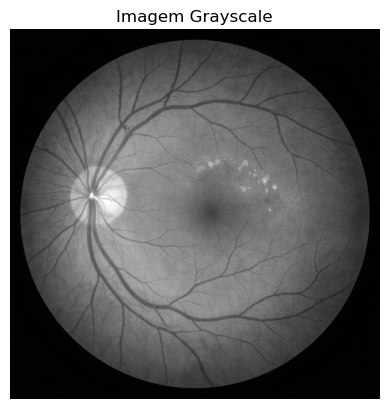

In [20]:
# ==============================
# Conversão manual RGB → Grayscale
# ==============================

def rgb_para_gray(img):
    """
    Converte imagem RGB para grayscale
    usando fórmula ponderada padrão:
    Gray = 0.299R + 0.587G + 0.114B
    """
    
    # Obter dimensões
    altura, largura, _ = img.shape
    
    # Criar imagem grayscale vazia
    gray = np.zeros((altura, largura))
    
    # Percorrer pixel a pixel
    for i in range(altura):
        for j in range(largura):
            
            R = img[i, j, 0]
            G = img[i, j, 1]
            B = img[i, j, 2]
            
            # Fórmula padrão luminância
            gray[i, j] = 0.299*R + 0.587*G + 0.114*B
    
    return gray


# Aplicar função
imagem_gray = rgb_para_gray(imagem)

# Mostrar resultado
plt.imshow(imagem_gray, cmap="gray")
plt.title("Imagem Grayscale")
plt.axis("off")
plt.show()

**Question 4**: Write a function that changes the pixel with intensity lower than 20 of a grayscale image to white pixels (255). Apply to the transformed image of question 3.

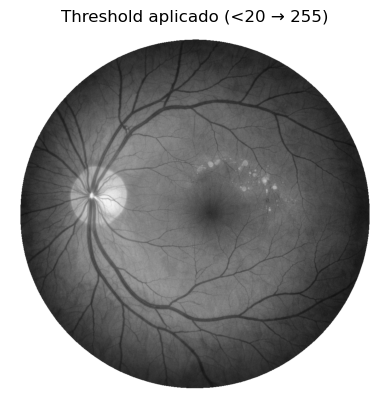

In [21]:
# ==============================
# Threshold: pixels < 20 tornam-se 255
# ==============================

def aplicar_threshold(img_gray, limite=20):
    """
    Se imagem estiver em 0–1, converte para 0–255.
    Depois aplica threshold:
    pixels < limite → 255
    """
    
    # Se a imagem estiver normalizada (0–1), converte para 0–255
    if img_gray.max() <= 1.0:
        img_gray = img_gray * 255
    
    # Garantir tipo uint8
    img_gray = img_gray.astype(np.uint8)
    
    # Criar cópia
    resultado = img_gray.copy()
    
    # Aplicar threshold de forma vetorizada (mais eficiente)
    resultado[resultado < limite] = 255
    
    return resultado


# Aplicar
imagem_threshold = aplicar_threshold(imagem_gray, 20)

# Mostrar resultado
plt.imshow(imagem_threshold, cmap="gray")
plt.title("Threshold aplicado (<20 → 255)")
plt.axis("off")
plt.show()